# 4. Deriving Scale Factors
Tutorial on deriving b tagging scale factors (SF) to correct the discriminator shape in Monte Carlo simulation.

The scale factors to correct b jets are derived in a $t\bar{t}$ phase space, they are derived differential in the jet's transverse momentum to avoid the sculpting of this variable.
Due to the short time available in this tutorial and to avoid waiting for processing, the distributions to measure the SFs are provided in form of histograms of the b tag score for multiple bins of the transverse momentum.



First import the packeges we will need:
- uproot to read in the histograms
- numpy for calculations
- matplotlib for plotting
- scipy for the interpolation
- correctionlib for saving the scale factors in a common format used in CMS

In [1]:
import uproot

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from scipy.interpolate import PchipInterpolator, PPoly

In [5]:
import correctionlib.schemav2 as cs

Read in the histograms for the differnet $p_T$ bins, for data and MC (splitted into light and heavy falvour).

In the name of the individual histograms you can also find information about $|\eta|$ and $\Delta R$, variables the in which the SFs can be differential, but these are not used in this tutorial. The $p_T$ edges used for this tuturial are defined below.

In [6]:
hists = uproot.open("/work/projects/hats2024/tagging/hists.root")

# On lxplus, use path /eos/cms/store/group/phys_btag/PODAS/Exercise3/

In [7]:
hists.keys()

['HF_deepjet_pt20to30_eta0to2.5_dr0toinf_data;1',
 'HF_deepjet_pt20to30_eta0to2.5_dr0toinf_light;1',
 'HF_deepjet_pt20to30_eta0to2.5_dr0toinf_heavy;1',
 'HF_deepjet_pt30to50_eta0to2.5_dr0toinf_data;1',
 'HF_deepjet_pt30to50_eta0to2.5_dr0toinf_light;1',
 'HF_deepjet_pt30to50_eta0to2.5_dr0toinf_heavy;1',
 'HF_deepjet_pt50to70_eta0to2.5_dr0toinf_data;1',
 'HF_deepjet_pt50to70_eta0to2.5_dr0toinf_light;1',
 'HF_deepjet_pt50to70_eta0to2.5_dr0toinf_heavy;1',
 'HF_deepjet_pt70to100_eta0to2.5_dr0toinf_data;1',
 'HF_deepjet_pt70to100_eta0to2.5_dr0toinf_light;1',
 'HF_deepjet_pt70to100_eta0to2.5_dr0toinf_heavy;1',
 'HF_deepjet_pt100to140_eta0to2.5_dr0toinf_data;1',
 'HF_deepjet_pt100to140_eta0to2.5_dr0toinf_light;1',
 'HF_deepjet_pt100to140_eta0to2.5_dr0toinf_heavy;1',
 'HF_deepjet_pt140toinf_eta0to2.5_dr0toinf_data;1',
 'HF_deepjet_pt140toinf_eta0to2.5_dr0toinf_light;1',
 'HF_deepjet_pt140toinf_eta0to2.5_dr0toinf_heavy;1']

In [8]:
pt_edges = [(20,30), (30,50), (50,70), (70,100), (100,140), (140, np.inf)]
pt_bins = [f"{lower}to{upper}" for lower, upper in pt_edges]
flavors = ["heavy", "light", "data"]
def get_data(pt_bin: str, flavor: str):
    return hists.get(f"HF_deepjet_pt{pt_bin}_eta0to2.5_dr0toinf_{flavor};1")

After reading in the historagams it's your turn to start with the SF derivation. Your first tasks will be:

1. to normalise the MC to the data yield in each $p_T$ bin (we only want to correct the MC shape not the MC yield)
2. to plot the data to MC agreement for each $p_T$ bin:
    - you can use bar(x, y, width=...) for the MC to produce a plot similar to a histogram
    - calculate the ratio between data and MC and plot it below the histogram

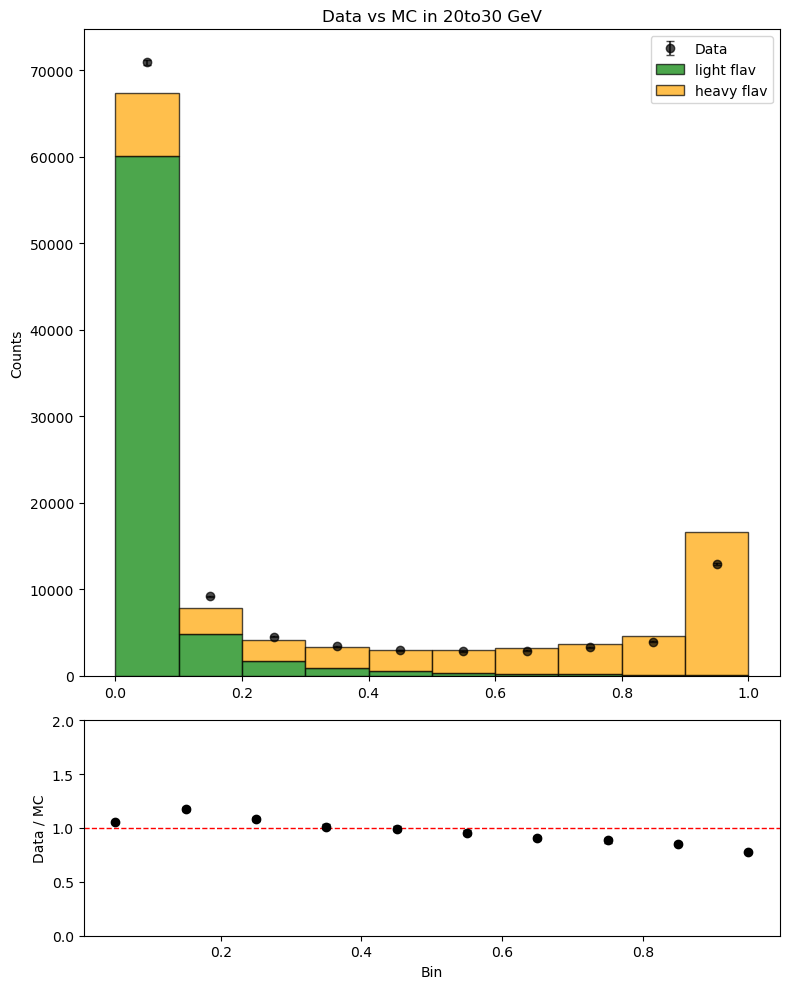

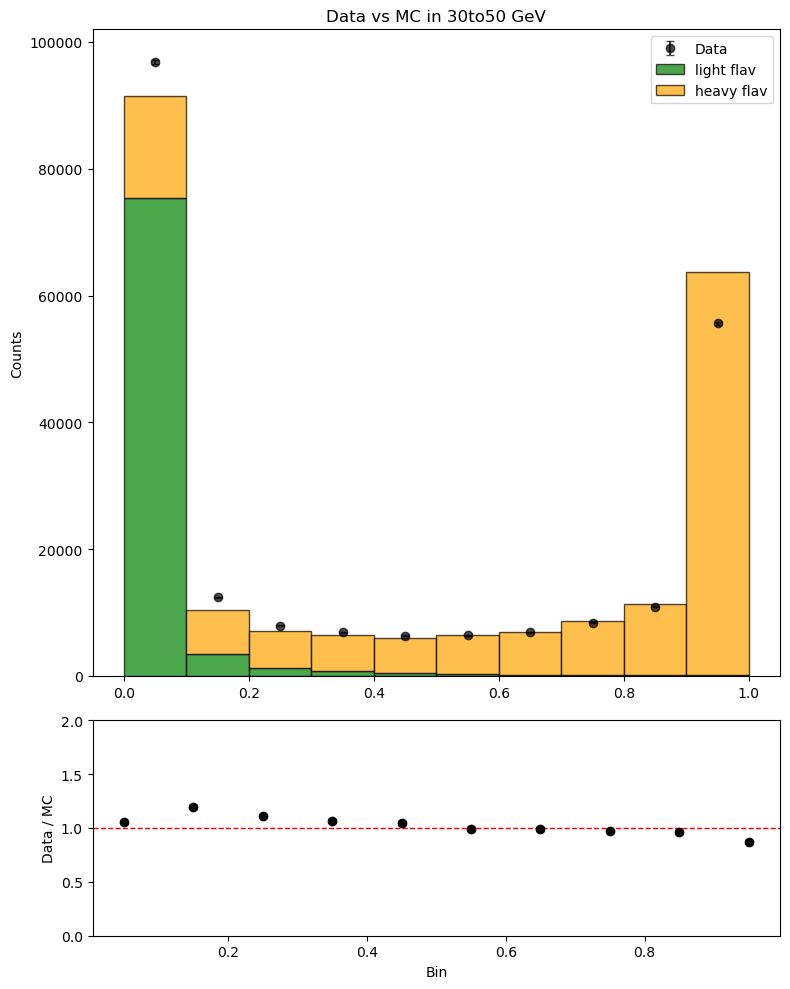

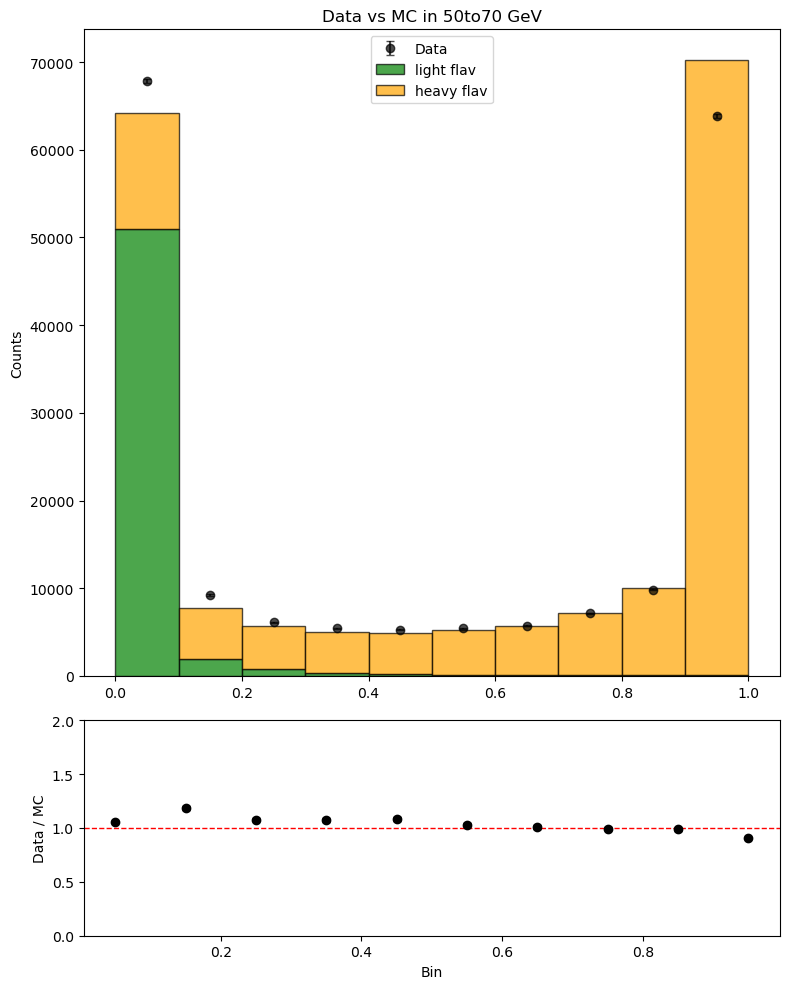

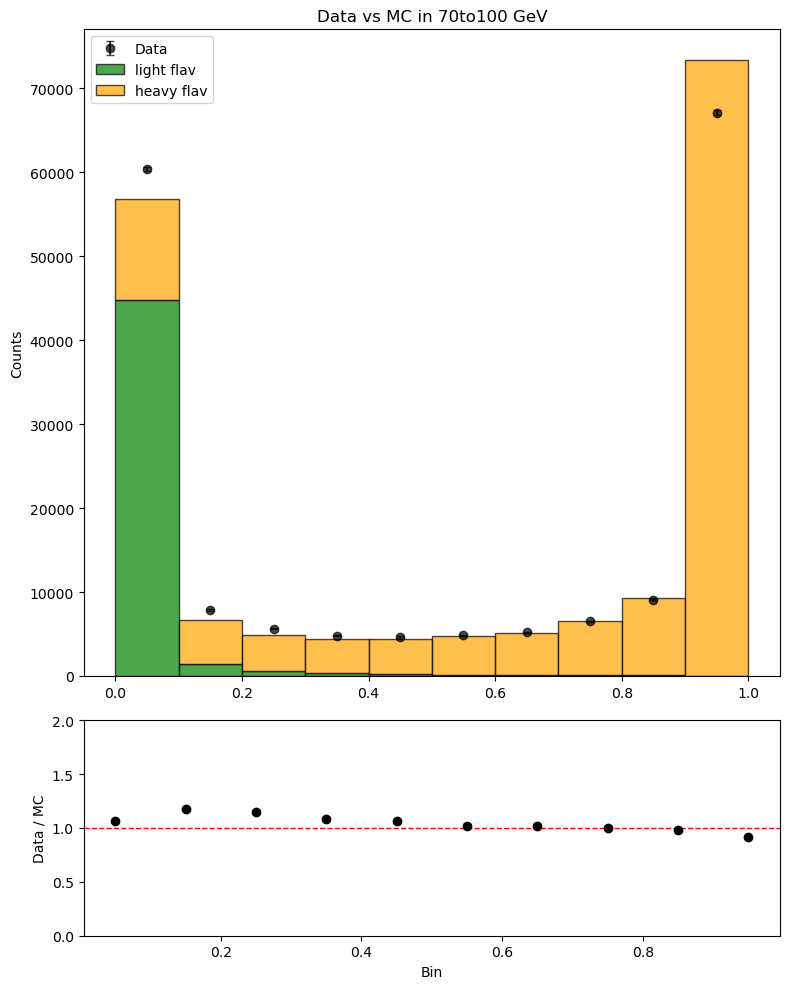

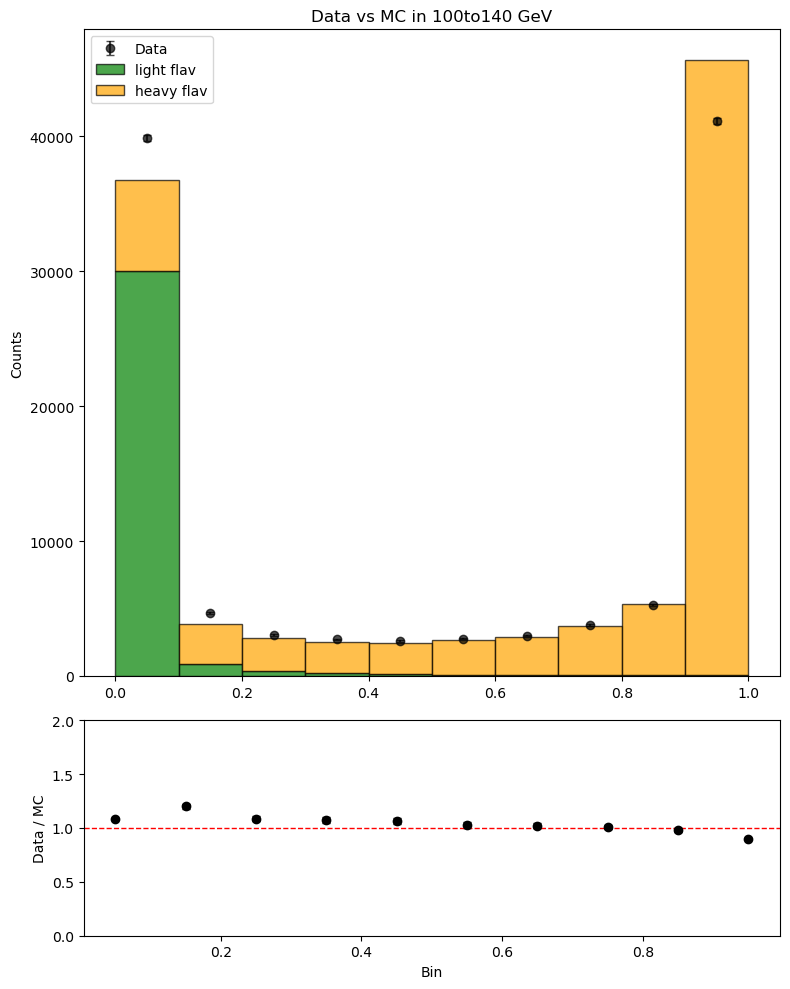

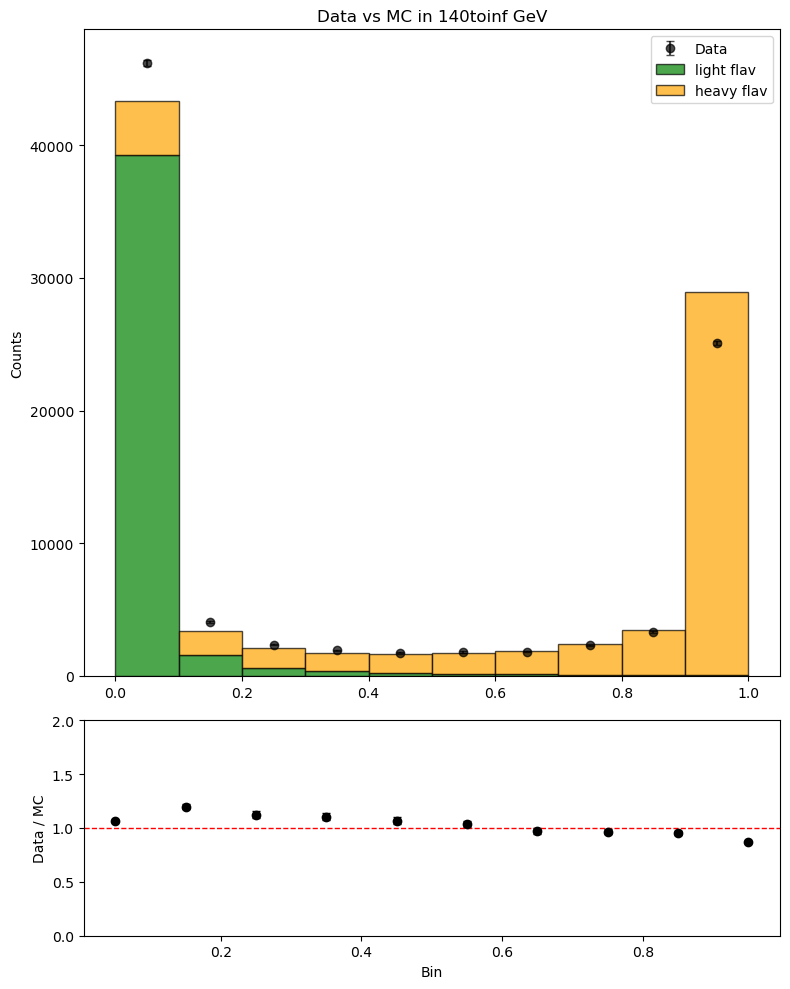

In [9]:
for pt_bin in pt_bins:
    data_values, data_edges = get_data(pt_bin, "data").to_numpy()
    heavy_values = get_data(pt_bin, "heavy").values().copy()
    light_values = get_data(pt_bin, "light").values().copy()

    mc_counts = heavy_values+light_values
    heavy_values_norm = heavy_values*(np.sum(data_values)/np.sum(mc_counts))
    light_values_norm = light_values*(np.sum(data_values)/np.sum(mc_counts))


    mc_counts_norm = heavy_values_norm+light_values_norm
    # Bin centers for plotting
    bin_centers = 0.5 * (data_edges[:-1] + data_edges[1:])
    widths = (data_edges[:-1] - data_edges[1:])

    # Plotting data and MC
    fig, ax = plt.subplots(2, 1, figsize=(8, 10), gridspec_kw={'height_ratios': [3, 1]})

    errors = np.sqrt(data_values)
    # Top plot: Histogram-like bar plot
    ax[0].errorbar(bin_centers, data_values, yerr=errors, fmt='o', label='Data', alpha=0.7, color='black', capsize=3)
    ax[0].bar(bin_centers, light_values_norm, width=widths, label='light flav', alpha=0.7, color='green', edgecolor='black')
    ax[0].bar(bin_centers, heavy_values_norm, width=widths, bottom=light_values_norm,label='heavy flav', alpha=0.7, color='orange', edgecolor='black')
    ax[0].set_ylabel("Counts")
    ax[0].legend()
    ax[0].set_title(f"Data vs MC in {pt_bin} GeV")

    # Calculate ratio and handle division by zero
    ratio = np.divide(data_values, mc_counts_norm, out=np.zeros_like(data_values, dtype=float), where=mc_counts != 0)
    ratio_errors = ratio * np.sqrt((errors / data_values)**2 + (np.sqrt(mc_counts_norm) / mc_counts)**2)  # Error propagation
    
    # Bottom plot: Ratio plot with error bars
    ax[1].errorbar(bin_centers, ratio, yerr=ratio_errors, fmt='o', color='black', capsize=3)
    ax[1].axhline(1, color='red', linestyle='--', linewidth=1)  # Reference line at ratio = 1
    ax[1].set_xlabel("Bin")
    ax[1].set_ylabel("Data / MC")
    ax[1].set_ylim(0, 2)  # Set a reasonable y-axis limit

    plt.tight_layout()
    plt.show()

Now we will start to derive the SFs for each $p_T$ bin individually. As a first step you can calculate the SFs from the histogram counts provided in the following way:

1. First we have to normalise again to only account for shape changing effects in our SFs.
2. As we want to derive SFs for heavy (b) flavoured jets, we need to deal with the light (light + c) flavour contamination. To do so we will subtract the MC prediction for the contamination from data, to get an estimate of the heavy flavour contribution in data.$^*$
3. Now we can calculate the factor by which we have to scale the heavy MC to match the contamination free data. This is done for each bin in the b tag score and each $p_T$ bin.
4. To create a smooth SF we will now interpolate the SFs between the b tag score bins. You can use the [<tt>PchipInterpolator</tt>](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.PchipInterpolator.html) for a piecewise polynomial interpolation to cubic order. You can get the coefficients and breakpoints in the power basis with [<tt>PPoly</tt>](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.PPoly.html#scipy.interpolate.PPoly). 

    **Hint**: You can use: <tt>interpolator = PchipInterpolator()</tt> and <tt>PPoly(interpolator.c, interpolator.x)</tt>
    
    **Question**: How do we describe the very first and very last bin?
    
5. Write the formula to calculate the SFs in term of coefficients and breakpoints. Use the notation: $(x >= x_{min})*(x < x_{max})*[c_0(x - x_{BP})*(x - x_{BP})*(x - x_{BP}) + c_1(x - x_{BP})*(x - x_{BP})\,+\, ...]$ for the bin centers $x_{min}$ and the bin center of the following bin $x_{max}$ and the breakpoints of the interpolater $x_{BP}$. The first term makes sure you are only apply the piece wise interpolation to the correct bin by a heavyside function, the second form represents the interpolation. Make sure to get your parentheses right :)
6. Now you can plot the SFs together with the interpolation.

$*$ Of course we can expect the light flavour contribution to also have some shape differences between data and MC, such that the contamination would also be affected by some light flavour SFs. This is why these SFs are usually derived in an iterative procedure, in which first heavy and light SFs are derived separately and in the second iteration the contamination will be corrected by the SFs from the first iteration.

In [156]:
functions = []
SFs=[]
for pt_bin in pt_bins:
    data_values, data_edges = get_data(pt_bin, "data").to_numpy()
    heavy_values = get_data(pt_bin, "heavy").values().copy()
    light_values = get_data(pt_bin, "light").values().copy()
    
    mc_counts = heavy_values+light_values
    heavy_values_norm = heavy_values*(np.sum(data_values)/np.sum(mc_counts))
    light_values_norm = light_values*(np.sum(data_values)/np.sum(mc_counts))


    mc_counts_norm = heavy_values_norm+light_values_norm
    # Bin centers for plotting
    centers = 0.5 * (data_edges[:-1] + data_edges[1:])
    widths = (data_edges[:-1] - data_edges[1:])
    
    data_values_lm = data_values-light_values_norm # subtract D-L
    SF_ptbin = data_values_lm/heavy_values_norm # And to question 3 ( norm factor of heavy flavour alone)
    SFs.append(SF_ptbin)
    # Extrapolate for values outside the first and last bins
    x_first, x_last = centers[0], centers[-1]
    SF_first, SF_last = SF_ptbin[0], SF_ptbin[-1]    
    
    # writing the piecewise function:
    # piecewise function
    interpolator = PchipInterpolator(centers, SF_ptbin)
    ppoly_interpolator = PPoly(interpolator.c, interpolator.x)
    
    function_pieces = []
    # left side (Heavyside function for first bin)
    # Add constant extrapolation for values outside the range
    function_pieces.insert(0, f"(x<{x_first})*{SF_first:.6f}")


    # intermediate (degree 3 polynomial, power basis)
    # some code to help write the function
    for interpolator_idx, (x_min, x_max) in enumerate(zip(centers, centers[1:])):
        interpolator_coefficients = ppoly_interpolator.c[:, interpolator_idx]
        if any(np.isnan(interpolator_coefficients)):
          raise ValueError("One or more coefficient(s) is NaN!")
        x_BP = ppoly_interpolator.x[interpolator_idx] # breakpoints
        #     add the function here:
        degree = len(interpolator_coefficients) - 1
        function_piece = " + ".join(f"{coeff:.6f}*((x-{x_BP:.6f})^{degree - i})" for i, coeff in enumerate(interpolator_coefficients))
        #     multiply by heavyside function
        function_pieces.append(f"(x>={x_min})*(x < {x_max})*({function_piece})")
    
        # right side (Heavyside function for last bin)
        function_pieces.append(f"(x>={x_last})*{SF_last:.6f}")
    # join pieces
    functions.append(" + ".join(function_pieces))
    # Print the final piecewise function
    print("Piecewise function for SF interpolation:")
    print(functions)

Piecewise function for SF interpolation:
['(x<0.05)*1.483741 + (x>=0.05)*(x < 0.15000000000000002)*(4.981499*((x-0.050000)^3) + -3.420566*((x-0.050000)^2) + 0.000000*((x-0.050000)^1) + 1.483741*((x-0.050000)^0)) + (x>=0.95)*0.775980 + (x>=0.15000000000000002)*(x < 0.25)*(392.961903*((x-0.150000)^3) + -65.316024*((x-0.150000)^2) + -0.534668*((x-0.150000)^1) + 1.454517*((x-0.150000)^0)) + (x>=0.95)*0.775980 + (x>=0.25)*(x < 0.35000000000000003)*(34.880106*((x-0.250000)^3) + 1.891827*((x-0.250000)^2) + -1.809016*((x-0.250000)^1) + 1.140851*((x-0.250000)^0)) + (x>=0.95)*0.775980 + (x>=0.35000000000000003)*(x < 0.45)*(-22.347400*((x-0.350000)^3) + 3.813858*((x-0.350000)^2) + -0.384247*((x-0.350000)^1) + 1.013748*((x-0.350000)^0)) + (x>=0.95)*0.775980 + (x>=0.45)*(x < 0.55)*(6.531310*((x-0.450000)^3) + -1.843470*((x-0.450000)^2) + -0.291898*((x-0.450000)^1) + 0.991115*((x-0.450000)^0)) + (x>=0.95)*0.775980 + (x>=0.55)*(x < 0.6500000000000001)*(32.389567*((x-0.550000)^3) + -3.937746*((x-0.550

The last step is to save the derived correction in the correctionlib json format. For this you can follow the [Correctionlib tutorial](https://cms-nanoaod.github.io/correctionlib/correctionlib_tutorial.html#Correctionlib-tutorial) and combine different examples for writing binned and formula based correction.

After defining your correction you can print and test it with <tt>corr.to_evaluator()</tt>. If your tests work out fine, you can save your correction as described in the tutorial.   

In [157]:
corrections_binning=[]
corrections_poly=[]
for i,pt_bin in enumerate(pt_bins): 
    data_values, data_edges = get_data(pt_bin, "data").to_numpy()
    # export to correctionlib

    ##this one is the binning based
    correction = cs.Correction(
        version=1,
        name=f"b_tag_scale_factor_{pt_bin}GeV",
        description=f"Scale factors for b-tagging as a function of b-tag score in pt range {pt_bin} GeV",
        inputs=[
            cs.Variable(name="b_tag_score", type="real")  # Input variable
        ],
        output=cs.Variable(name="SF", type="real"),  # Output variable
        data=cs.Binning(
            nodetype="binning",
            input="b_tag_score",
            edges=data_edges ,  # Add the upper edge of the last bin
            content=SFs[i],
            flow="clamp"  # Clamp to handle out-of-range values
        )
    )
    corrections_binning.append(correction)

    #### this one is the formula based
    cor_poly=cs.Correction(
        version=1,
        name=f"poly_b_tag_scale_factor_{pt_bin}GeV",
        description=f"Polynomial scale factors for b-tagging as a function of b-tag score in pt range {pt_bin} GeV",
        inputs=[
            cs.Variable(name="b_tag_score", type="real")  # Input variable
        ],
        output=cs.Variable(name="SF", type="real"),  # Output variable
        data=cs.Formula(
                    nodetype="formula",
                    variables=["b_tag_score"],
                    parser="TFormula",
                    expression=functions[i]
            )
    )
    corrections_poly.append(cor_poly)


##you can also try modifying the above code such corrections are by pt category ( cs.Category), such that you don't have to create a pt loop

In [158]:
# print correction
corrections_binning
corrections_poly
functions[1][9]


'1'

In [159]:
# check if your correction is working
corrections_binning[0].to_evaluator().evaluate(0.9) ## for jet pt in 20to30GeV, btag score of 0.9

corrections_binning[5].to_evaluator().evaluate(0.5) ## for jet pt in 140toinf GeV, btag score of 0.9

1.0394257307052612

In [160]:
corrections_poly[5].to_evaluator().evaluate(0.5)

1.060254745875

In [ ]:
# writing it all out (save you correction)


In [162]:
with open("mycorrections_binned.json", "w") as fout:
    fout.write(corrections_binning[0].json(exclude_unset=True))